In [1]:
import importlib
import sys
from pathlib import Path
import pandas as pd

root = Path.cwd().parent.parent
sys.path.insert(0, str(root / "code"))

data_path = root / "data"

out_path = root / "out"

import plot.plots as plots
import mining.candidate_mining as mining
import mining.symbolic_features as symbolic_features
import experiments.experiment as experiments
import mining.token_counting as counting
import mining.alert_tokenization as alert_tokenization
import mining.candidate_metrics as candidate_metrics
import mining.candidate_filters as candidate_filters

importlib.reload(alert_tokenization)
importlib.reload(plots)
importlib.reload(mining)
importlib.reload(symbolic_features)
importlib.reload(experiments)
importlib.reload(counting)
importlib.reload(candidate_metrics)
importlib.reload(candidate_filters)


from plot.plots import *
from mining.candidate_mining import *
from mining.symbolic_features import build_symbolic_features_from_candidates_cached
from experiments.experiment import simple_ablation_experiment_p
from mining.token_counting import count_itemsets_eclat
from mining.alert_tokenization import build_token_cache_for_scenario, save_token_cache
from mining.candidate_metrics import compute_candidate_metrics
from mining.candidate_filters import *

### Load labeled dataset

In [2]:
df = pd.read_parquet(os.path.join(data_path, "ait_ads/labeled_combined_ait_ads.parquet"), engine="pyarrow")

In [3]:
# make sure timestamps are datetime and sorted
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

# normalize category
df["category_norm"] = df["category"].astype(str).str.split(" - ").str[0].str.strip()

#### Set run parameters

In [4]:
run_name="eclat-mining-test"
output_dir = os.path.join(out_path, run_name)

os.makedirs(output_dir,exist_ok=True)
min_support=10

scorer_name = "split_bayes"
miner_name = "2-itemset"
scenario_name = "wheeler"

### Tokenize alerts

In [5]:
meta_df, X_tokens_all, vocab = build_token_cache_for_scenario(
    df=df,
    scenario_name=scenario_name,
    extra_meta_cols=["srcip", "dstip"]
)

save_token_cache(
    meta_df=meta_df,
    X_tokens_all=X_tokens_all,
    vocab=vocab,
    scenario_name=scenario_name,
    run_name=run_name,
)

Building token cache for scenario: wheeler
Tokenizing using 32 fields (out of 35 requested). 
Excluded fields: {'srcport', 'rule_firedtimes', 'dstport'}
Token cache built: 616161 row-alerts, 4419 unique tokens
Saving token cache for scenario 'wheeler' to disk...
Token cache saved to: /Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/tokens/wheeler


### Window based mining run (scenario local)

##### 1) Token counting

In [6]:
scenario_counts, scenario_attack_flags = window_based_mining(
    scenario_name=scenario_name,
    run_name=run_name,
    counter=count_itemsets_eclat,
    counter_kwargs={
        "k": 2,
        "min_support": 10,
    },
)

Running mining for precached scenario 'wheeler'...
Iterating precached windows for scenario 'wheeler'...
Loading token cache for scenario 'wheeler' from disk...
Token cache loaded: 616161 alerts, 4419 unique tokens
Slicing token cache by time: 2022-01-26 00:00:00+00:00 to 2022-01-26 12:00:00+00:00 (include_end=False)
Sliced window: 19578 alerts
Processing window 2022-01-26 00:00:00+00:00 to 2022-01-26 12:00:00+00:00...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/code/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/code/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


[wheeler] 2022-01-26 00:00:00+00:00 -> 2022-01-26 12:00:00+00:00 | n=19578 | benign=19578 | attack=0
Slicing token cache by time: 2022-01-26 12:00:00+00:00 to 2022-01-27 00:00:00+00:00 (include_end=False)
Sliced window: 15425 alerts
Processing window 2022-01-26 12:00:00+00:00 to 2022-01-27 00:00:00+00:00...
[wheeler] 2022-01-26 12:00:00+00:00 -> 2022-01-27 00:00:00+00:00 | n=15425 | benign=15425 | attack=0
Slicing token cache by time: 2022-01-27 00:00:00+00:00 to 2022-01-27 12:00:00+00:00 (include_end=False)
Sliced window: 16108 alerts
Processing window 2022-01-27 00:00:00+00:00 to 2022-01-27 12:00:00+00:00...
[wheeler] 2022-01-27 00:00:00+00:00 -> 2022-01-27 12:00:00+00:00 | n=16108 | benign=16108 | attack=0
Slicing token cache by time: 2022-01-27 12:00:00+00:00 to 2022-01-28 00:00:00+00:00 (include_end=False)
Sliced window: 21851 alerts
Processing window 2022-01-27 12:00:00+00:00 to 2022-01-28 00:00:00+00:00...
[wheeler] 2022-01-27 12:00:00+00:00 -> 2022-01-28 00:00:00+00:00 | n=2185

Save token counts to csv

In [7]:
os.makedirs(f"{output_dir}/csv/{scenario_name}", exist_ok=True)

scen = scenario_counts.get(scenario_name, [])

for i, (df_scen, n0, n1) in enumerate(scen):
    df_out = df_scen.copy()
    df_out["n0"] = n0
    df_out["n1"] = n1

    df_out.to_csv(
        f"{output_dir}/csv/{scenario_name}/token_counts_window_{i}.csv",
        index=False
    )

    print(f"Saved token counts for window {i} of scenario '{scenario_name}' to path '{output_dir}/csv/{scenario_name}/token_counts_window_{i}.csv'.")

Saved token counts for window 0 of scenario 'wheeler' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/wheeler/token_counts_window_0.csv'.
Saved token counts for window 1 of scenario 'wheeler' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/wheeler/token_counts_window_1.csv'.
Saved token counts for window 2 of scenario 'wheeler' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/wheeler/token_counts_window_2.csv'.
Saved token counts for window 3 of scenario 'wheeler' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/wheeler/token_counts_window_3.csv'.
Saved token counts for window 4 of scenario 'wheeler' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/wheeler/token_counts_window_4.csv'.
Saved token counts for window 5 of scenario 'wheeler' to path '/Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mi

Construct one counts dataframe over all windows (keeping candidates appearing in multiple windows)

In [13]:
scen = scenario_counts[scenario_name]

dfs = []
for window_id, (df_w, n0, n1) in enumerate(scen):
    tmp = df_w.copy()
    tmp["window_id"] = window_id
    tmp["n0"] = n0
    tmp["n1"] = n1
    dfs.append(tmp)

counts_df = pd.concat(dfs, ignore_index=True)

In [14]:
metrics_df = compute_candidate_metrics(counts_df)

In [15]:
metrics_df.columns

Index(['candidate', 'candidate_str', 'c0', 'c1', 'count_total', 'n0', 'n1',
       'window_id', 'is_benign_only_window', 'is_validation_window', 'appears',
       'min_total_support_count', 'window_frequency', 'benign_prevalence',
       'attack_prevalence', 'is_risky_window', 'avg_benign_prevalence',
       'n_benign_only_windows', 'avg_attack_prevalence',
       'n_candidate_validation_windows', 'n_validation_windows',
       'n_risky_windows', 'c0_total_validation', 'c1_total_validation',
       'risky_window_ratio', 'contrast_score', 'mean_contrast_score',
       'min_contrast_score', 'N', 'tf', 'idf', 'tfidf', 'mean_tfidf',
       'max_tfidf'],
      dtype='object')

In [ ]:
metrics_df.to_csv(f"{output_dir}/csv/{scenario_name}/{scenario_name}_candidate_metrics.csv",
        index=False)

##### 2) Stable candidate filter

In [ ]:
filtered_output_dir = f"{output_dir}/csv/{scenario_name}"
filtered_stable_df = filter_stable_candidates(metrics_df, output_dir=filtered_output_dir, scenario_name=scenario_name, min_support_count=min_support)

Removed  9569  unstable candidates, kept  4740
Saved stable features for scenario 'wheeler' to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/out/eclat-mining-test/csv/wheeler/wheeler_stable_features.csv


Index(['candidate', 'candidate_str', 'c0', 'c1', 'count_total', 'n0', 'n1',
       'window_id', 'benign_coverage', 'attack_coverage', 'score', 'appeared',
       'score_positive', 'mean_score', 'positive_ratio', 'score_std',
       'mean_benign_coverage', 'min_support_count', 'window_frequency',
       'score_cv'],
      dtype='object')

##### 3) General candidate filter

In [ ]:
# filtered_tfidf_df = filter_tfidf_candidates(tfidf_metrics_df)

# filtered_tfidf_df.to_csv(f"{output_dir}/csv/{scenario_name}/filtered_candidates.csv", index=False)

Removed 2361 candidates, kept 2124


##### 4) Discriminative power

In [ ]:
# filtered_disc_df = filter_discriminative_candidates(disc_metrics_df)
# filtered_disc_df.head()

# filtered_disc_df.to_csv(f"{output_dir}/csv/{scenario_name}/final_filtered_candidates.csv", index=False)

##### 6) Rank survivors

In [ ]:
# # remove duplicates and rank candidates by mean TF-IDF score
# ranked_df = filtered_tfidf_df.sort_values(
#     by=["mean_tfidf", "window_frequency_ratio", "mean_benign_coverage"],
#     ascending=[False, False, False]
# ).drop_duplicates(subset=["candidate_str"], keep="first")

### Attach tidset to survivors

In [ ]:
# base_dir = os.path.join(output_dir, "tokens", scenario_name)

# survivors = ranked_df.head(20)
# survivors = attach_tidsets_to_survivors(
#     survivors=survivors,
#     x_tokens_path=os.path.join(base_dir, "X_tokens.npz"),
#     vocab_path=os.path.join(base_dir, "vocab.json"),
# )

In [ ]:
# survivors["tidset"].apply(len).describe()

count        20.000000
mean     418870.950000
std         320.808924
min      418648.000000
25%      418648.000000
50%      418685.000000
75%      419348.000000
max      419348.000000
Name: tidset, dtype: float64

##### 7) Validation

Build symbolic features from survivors

In [ ]:
# # Build symbolic features from the surviving candidates for the given scenario
# df_s = df[df["scenario"] == scenario_name].copy()

# X_sym = build_symbolic_features_from_candidates_cached(
#     df_used=df_s,
#     surviving_candidates_df=survivors,
#     scenario_name=scenario_name,
#     run_name=run_name,
#     tokens_base_dir=output_dir,
#     id_col="alert_id",
#     tx_col="_tx_id",
#     min_fires=1,
# )

Run simple ablation experiment with survivors

In [ ]:
# window_size = pd.Timedelta(days=1)

# out_dir = os.path.join(output_dir, f"plots/{scenario_name}")
# os.makedirs(out_dir, exist_ok=True)

In [ ]:
# res = simple_ablation_experiment_p(
#     df=df_s,
#     X_sym=X_sym,
#     window_size=window_size,
#     scenario_name=scenario_name,
# )


Running scenario = wheeler (616161 alerts)
Built features: 10 static cols, 20 symbolic cols

Training BASELINE model...

Training base + 'is_mined__wazuh:agent_name=wazuh-client__AND__wazuh:rule_groups_json=web' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(



Training base + 'is_mined__wazuh:alert_channel=host__AND__wazuh:rule_groups_json=web' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(



Training base + 'is_mined__wazuh:input_type=log__AND__wazuh:rule_groups_json=web' ...


...

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(



Training base + 'is_mined__wazuh:log_source_path=/var/log/apache2/intranet-access.log__AND__wazuh:rule_groups_json=web' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(



Training BASE + ALL symbolic features...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(



BASE: {'auc': 0.9959726145582102}
BASE+SYM: {'auc': 0.996696005680421} 

BASE FEATS:  ['source_aminer', 'source_wazuh', 'wazuh_level', 'ids_severity', 'has_username', 'has_procname', 'has_rule_id', 'has_mitre', 'is_internal_ip', 'src_eq_dst']
SYM FEATS:  ['is_mined__wazuh:agent_name=wazuh-client__AND__wazuh:rule_groups_json=web', 'is_mined__wazuh:alert_channel=host__AND__wazuh:rule_groups_json=web', 'is_mined__wazuh:input_type=log__AND__wazuh:rule_groups_json=web', 'is_mined__wazuh:is_ids_alert=0__AND__wazuh:rule_groups_json=web', 'is_mined__wazuh:manager_name=wazuh.manager__AND__wazuh:rule_groups_json=web', 'is_mined__wazuh:rule_groups_json=web__AND__wazuh:source=wazuh', 'is_mined__wazuh:agent_name=wazuh-client__AND__wazuh:decoder=web-accesslog', 'is_mined__wazuh:alert_channel=host__AND__wazuh:decoder=web-accesslog', 'is_mined__wazuh:decoder=web-accesslog__AND__wazuh:input_type=log', 'is_mined__wazuh:decoder=web-accesslog__AND__wazuh:is_ids_alert=0', 'is_mined__wazuh:decoder=web-acce

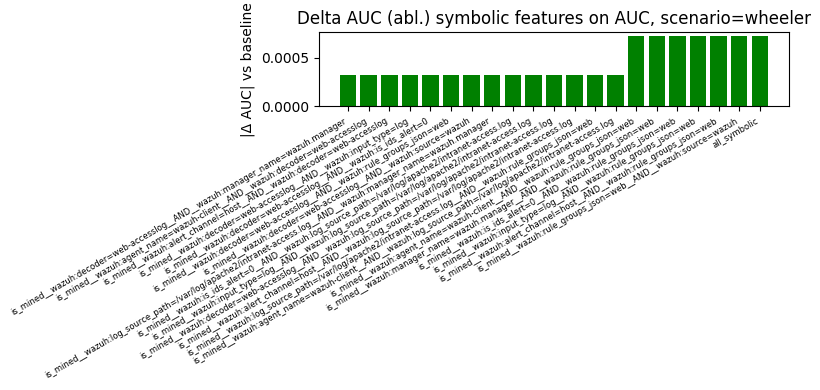

In [ ]:
# diag_base = res["diag_base"]
# diag_symbolic_all = res["diag_sym_all"]

# print("\nBASE:", diag_base)
# print("BASE+SYM:", diag_symbolic_all, "\n")

# print("BASE FEATS: ", res["base_feats"])
# print("SYM FEATS: ", res["sym_feats"])

# results_dict = {"base": res["diag_base"]}
# for feat, diag in res["diag_ablation"].items():
#     results_dict[feat] = diag
# results_dict["all_symbolic"] = res["diag_sym_all"]

# plot_symbolic_performance_delta(
#         results_dict,
#         scenario_name=scenario_name,  
#         metric="auc",
#         out_dir=out_dir
# )